In [3]:
from Bio import SeqIO
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error as rmse
from scipy.stats import pearsonr

# choose models to include
models = [
    'PRIME',
    'TemStaPro',
    'PPTStab',
    'DeepSTABp',
    'TemBERTure',
    'ThermoFormer',
    'TmProt',
    'FINE_650M_FULL_MELTOME',
    'FINE_650M_FLIP',
    'FINE_650M_NO_INT',
    'FINE_3B_NO_INT'
]

# Choose TPP test sets
groups_tpp = [
    '1_TEST',
    '3_REVERSED',
    '4_SHUFFLED',
    '2_FIRST_100',
]

# Choose DSC test sets
groups_dsc = [
    'scoop',
    'nanomelt',
    'csp',
    'petases',
]


# Make dict for accessing protein information easily, see cell below for example
big_tpp_file = SeqIO.parse('../data/TPP/tpp.fasta', "fasta")
big_fasta_labels = dict()

for rec in big_tpp_file:
    d = {_n.split('=')[0]: _n.split('=')[-1] for _n in rec.name.split(';')}
    d['tm'] = float(d['tm'])
    d['seq'] = str(rec._seq)  # remove str(..) if you want access to SeqIO.Seq methods
    big_fasta_labels[d['protein_id']] = d

dsc_labels = dict()

for dsc_file in groups_dsc:
    data = SeqIO.parse(f'../data/DSC/{dsc_file}.fasta', "fasta")
    dsc_labels[dsc_file] = dict()
    for rec in data:
        d = {_n.split('=')[0]: _n.split('=')[-1] for _n in rec.name.split(';')}
        d['tm'] = float(d['tm'])
        d['seq'] = str(rec._seq)
        dsc_labels[dsc_file][d['protein_id']] = d

TemBERTure


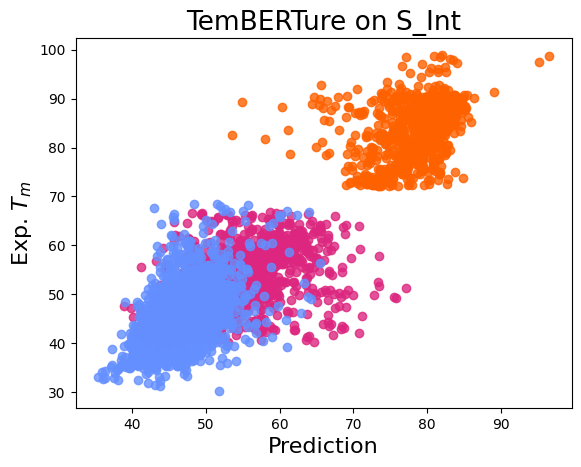

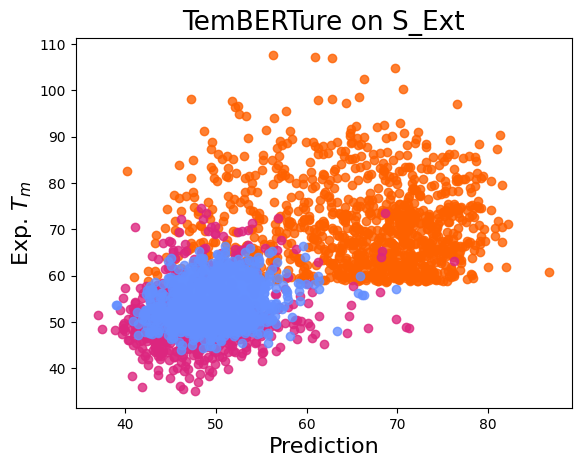

TmProt


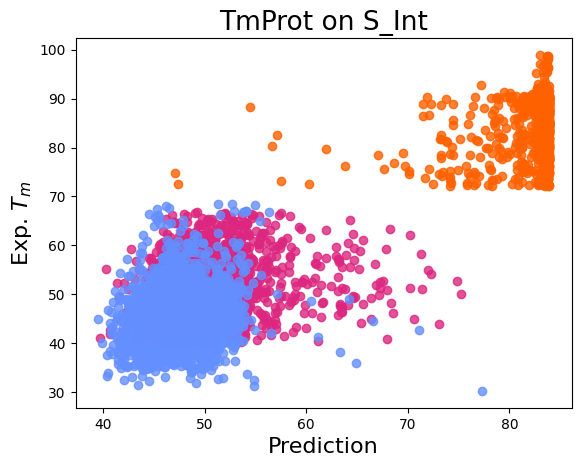

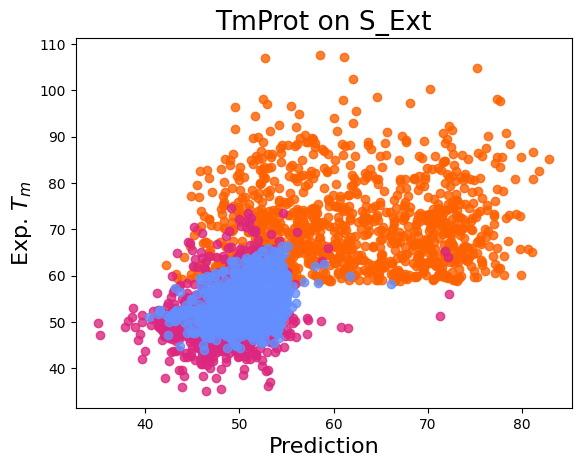

PRIME


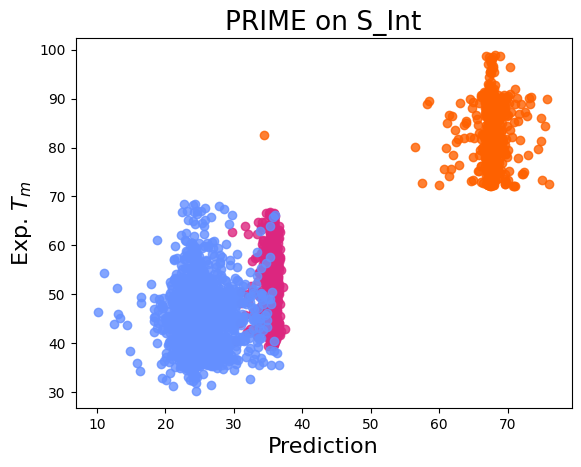

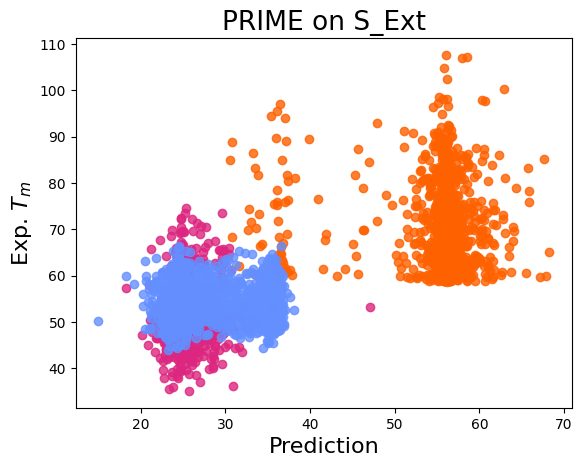

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# sns.set_style('whitegrid')

color_palettes = {'blue': '#648FFF', 'purple': '#785EF0', 'pink': '#DC267F', 'orange': '#FE6100', 'yellow': '#FE6100'}
colors = [color_palettes['orange'], color_palettes['pink'], color_palettes['blue'],]

# Make TPP plots showing correlation perorganisms

# refers to S_int and S_ext from the paper
test_species = {
    'Int':
        ['T.thermophilus',
        'E.coli',
        'A.thaliana'], 
    'Ext':
        ['Geobacillusthermoleovorans',
        'Trypanosomacruzi',
        'Toxoplasmagondii']
}

models_to_check = [
    'TemBERTure',
    'TmProt',
    'PRIME'
]

for mod in models_to_check:
    print(mod)
    big_results = pd.read_csv(f'../results/{mod}/1_TEST.csv')
    name_2_pred = big_results.set_index('name').to_dict()['pred']
    name_2_exp = big_results.set_index('name').to_dict()['exp_tm']
    for sp_group in test_species:
        for sp_i, sp in enumerate(test_species[sp_group]):
            names_in_this_sp = [name for name in big_results['name'] if big_fasta_labels[name]['sp'] == sp]
            predictions_in_this_sp = [name_2_pred[name] for name in names_in_this_sp]
            exp_values = [name_2_exp[name] for name in names_in_this_sp]
            plt.plot(predictions_in_this_sp, exp_values, 'o', label = sp, alpha = 0.8, color = colors[sp_i])
        plt.title(f'{mod} on S_{sp_group}', fontsize = 19)
        # plt.xlim(10,110)
        # plt.ylim(10,110)
        # plt.xlabel('Prediction', fontsize = 16)
        # plt.ylabel('Exp. $T_m$', fontsize = 16)
        plt.show()